# MIG Cement Demand Forecasting — Step 3: Exploratory Data Analysis

**Scope of this notebook:** now that the data is clean (Data Cleaning) and we know its basic
shape (Data Profiling), we run a structured EDA — descriptive statistics, univariate analysis,
bivariate analysis against the target, and multivariate analysis — before closing with the
specific business findings that shape the forecasting model in Step 4.

**Target variable:** `consumed_tonnes` — the daily tonnes of cement actually used at a site.
This is what we're ultimately forecasting 8 weeks ahead, so every bivariate/multivariate section
below is anchored on its relationship with this column.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style("whitegrid")

TARGET = "consumed_tonnes"

df = pd.read_parquet("../outputs/cement_demand_clean.parquet")
numeric_cols = [
    "consumed_tonnes", "planned_pour_tonnes", "opening_inventory_tonnes",
    "deliveries_tonnes", "closing_inventory_tonnes", "rain_mm", "avg_temp_c",
    "silo_capacity", "capacity_utilization",
]
categorical_cols = ["region", "behavior", "cement_type", "is_weekend"]
df.shape


(32880, 21)

## 1. Primary Dataset Exploratory Data Analysis

### 1.1 Descriptive Statistics

Standard summary statistics for every numeric column, plus skewness and kurtosis — skewness
tells us whether a distribution leans left/right of its mean, kurtosis tells us how heavy its
tails are (both matter for choosing whether a model needs to handle non-normal residuals).


In [2]:
desc = df[numeric_cols].describe().T
desc["skew"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurtosis()
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
consumed_tonnes,"32,880.00",23.72,16.85,0.00,10.71,19.72,36.49,69.97,0.44,-0.67
planned_pour_tonnes,"32,880.00",30.70,19.49,0.00,12.83,33.46,47.61,69.98,-0.04,-1.30
opening_inventory_tonnes,"32,880.00","3,066.68","5,586.03",0.00,1.28,50.71,"3,298.52","20,646.18",1.72,1.55
deliveries_tonnes,"32,880.00",29.29,12.33,0.00,19.30,29.49,39.75,50.00,-0.18,-0.84
closing_inventory_tonnes,"32,880.00","3,072.25","5,593.02",0.00,1.27,50.66,"3,312.06","20,658.87",1.71,1.55
rain_mm,"32,880.00",5.01,5.00,0.00,1.44,3.47,6.97,50.00,1.97,5.57
avg_temp_c,"32,880.00",10.09,8.52,-5.00,3.34,9.99,16.70,35.00,0.10,-0.82
silo_capacity,"32,880.00",317.53,112.81,120.00,230.00,314.00,437.00,487.00,-0.04,-1.12
capacity_utilization,"32,880.00",11.74,25.02,0.00,0.00,0.17,10.52,172.16,3.01,10.58


**Reading it:** most operational columns (`consumed_tonnes`, `planned_pour_tonnes`,
`rain_mm`, `avg_temp_c`) have skew close to 0 — roughly symmetric, well-behaved distributions.
`closing_inventory_tonnes` and `capacity_utilization` are heavily right-skewed with very high
kurtosis — a small number of sites (the conservative-behaviour ones we'll confirm below) pull
these columns' distributions out into a long right tail.


### 1.2 Univariate Analysis

#### 1.2.1 Univariate Analysis: Numerical Features

Distribution shape for each numeric column on its own, before we relate anything to anything
else.


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

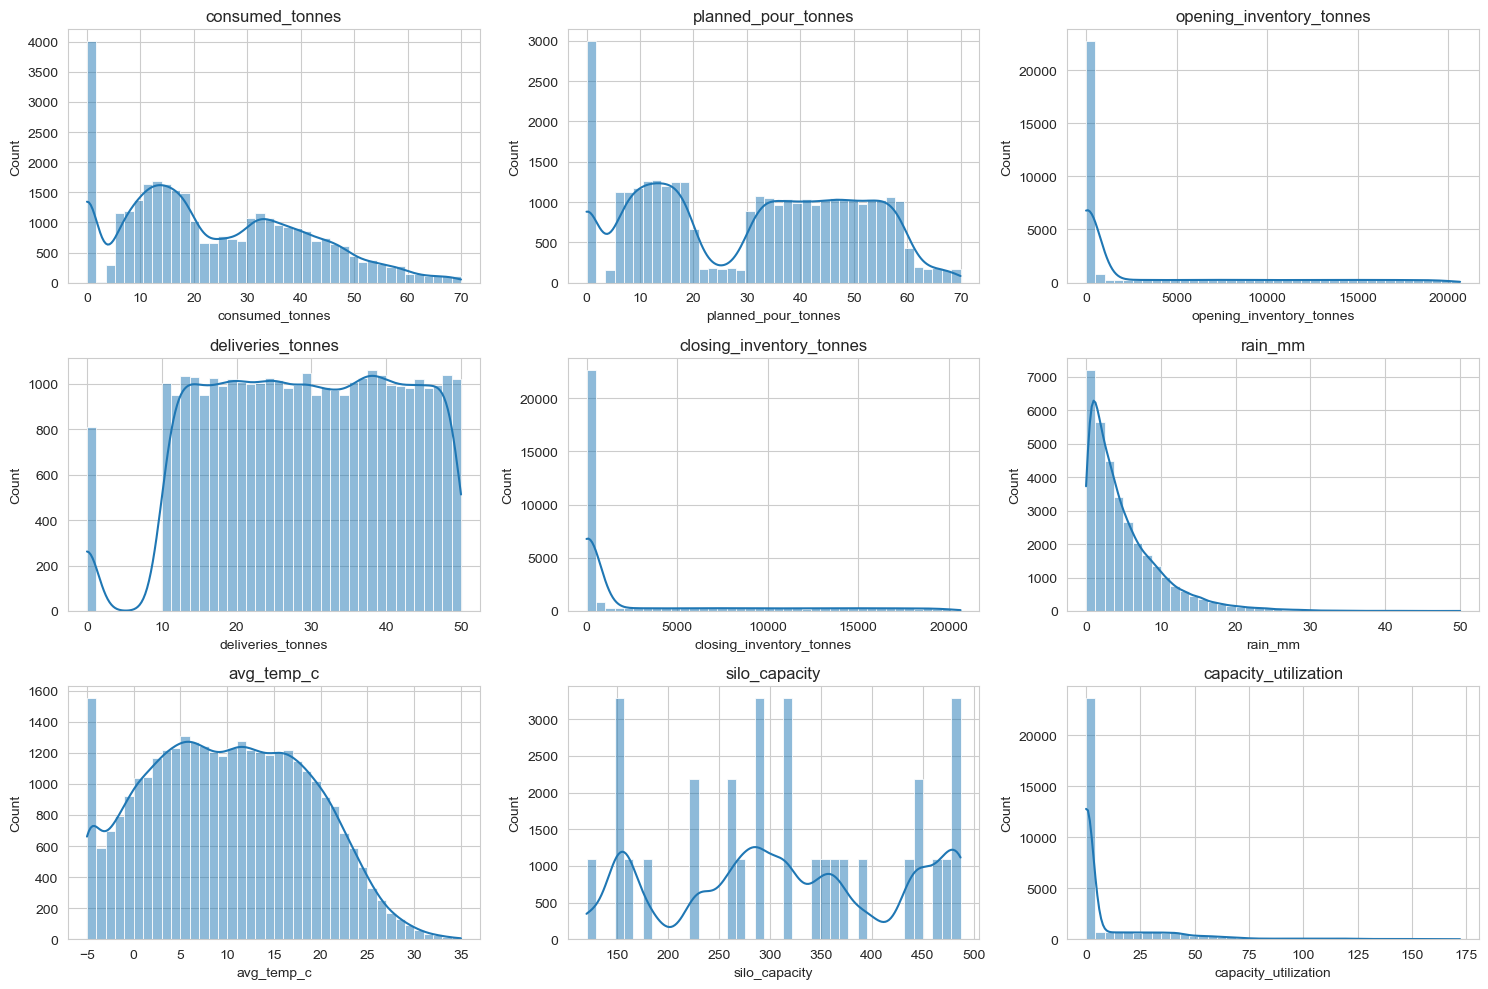

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()


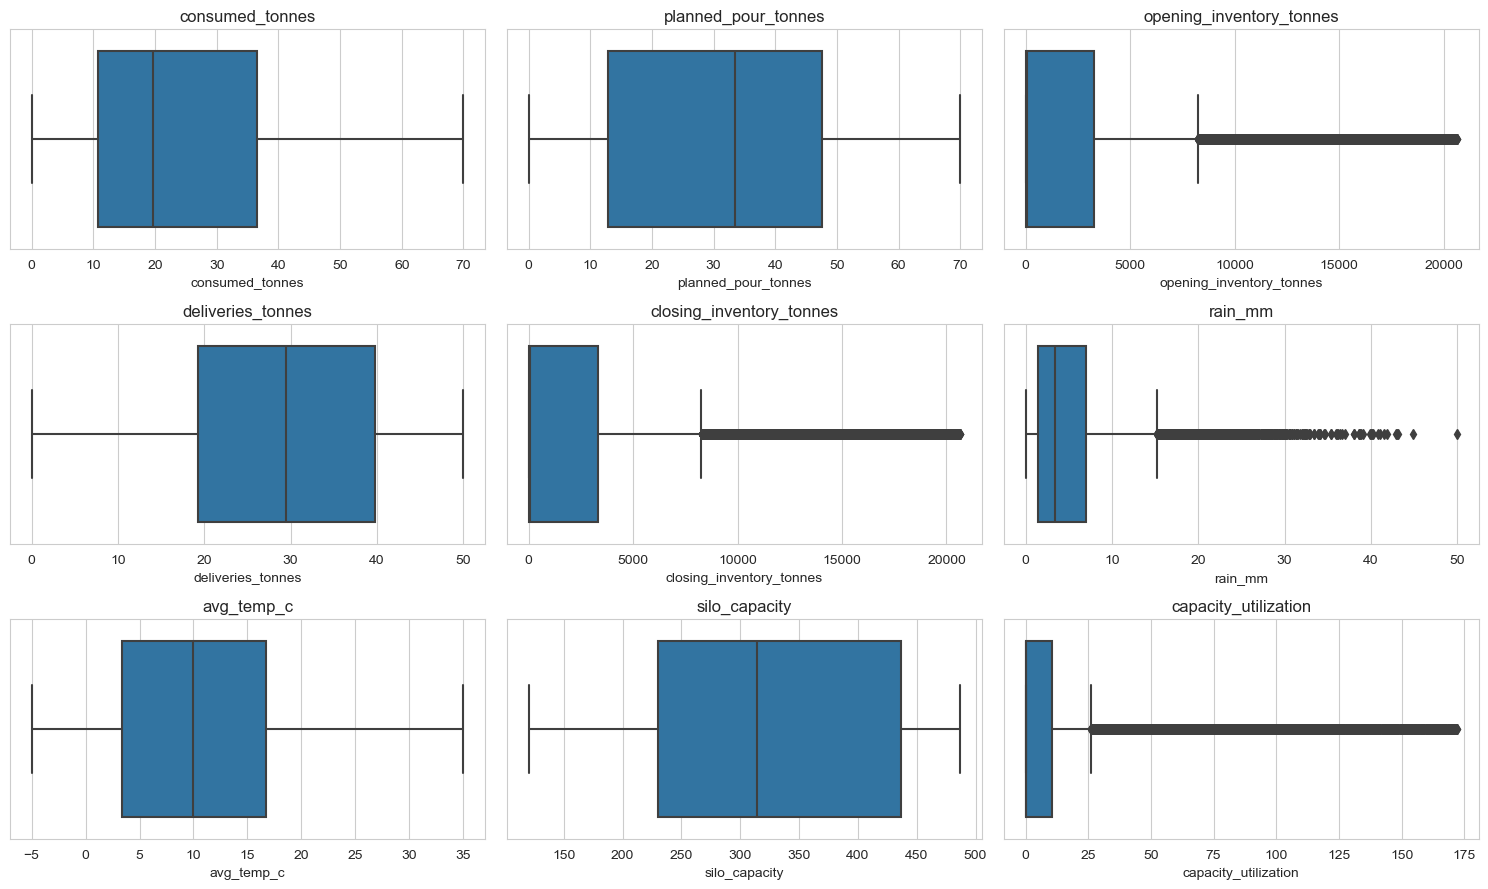

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Reading it:** the tonnage/weather columns are roughly bell-shaped with modest boxplot
whiskers. `closing_inventory_tonnes` and `capacity_utilization` show the same long-tail pattern
flagged in the descriptive stats — visually confirmed here as a cluster of extreme values well
above the box, not scattered noise.


#### 1.2.2 Univariate Analysis: Categorical Features

How the categorical dimensions are distributed — group sizes matter because small groups
produce noisier averages later in bivariate analysis.


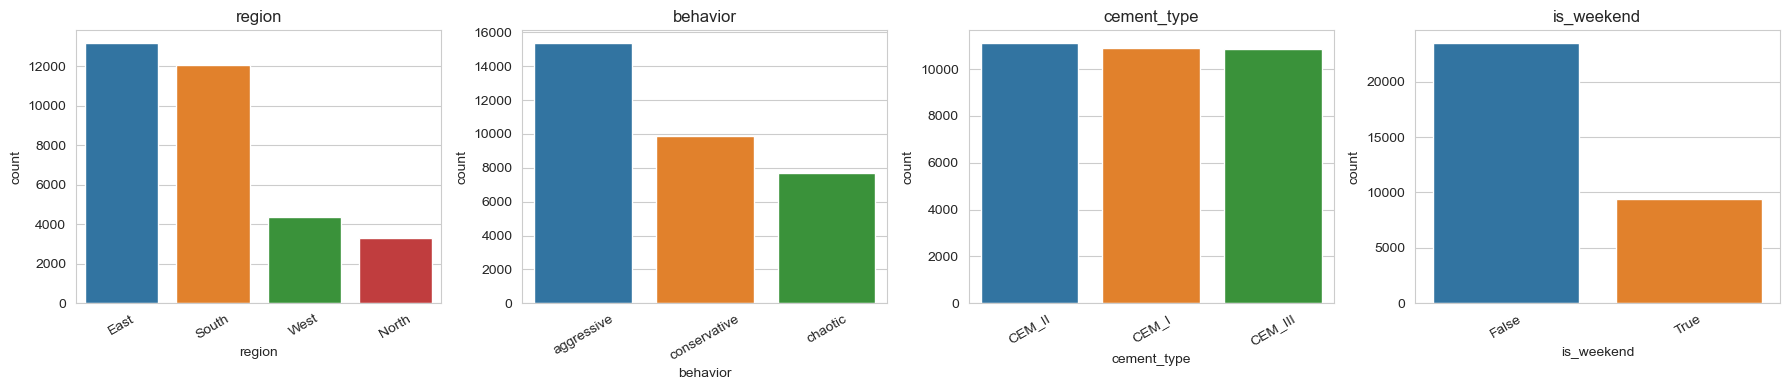

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes.flat, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


**Reading it:** cement types are almost evenly split (as expected — 3 grades, similar row
counts). Regions are fairly balanced. Behaviour is not: aggressive sites (14) roughly double
conservative (9) and double chaotic (7) in count — worth remembering when comparing group means,
since the conservative group's averages rest on fewer sites.


#### 1.2.3 Target Variable Analysis

A closer look at `consumed_tonnes` specifically, since it's what we're forecasting.


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


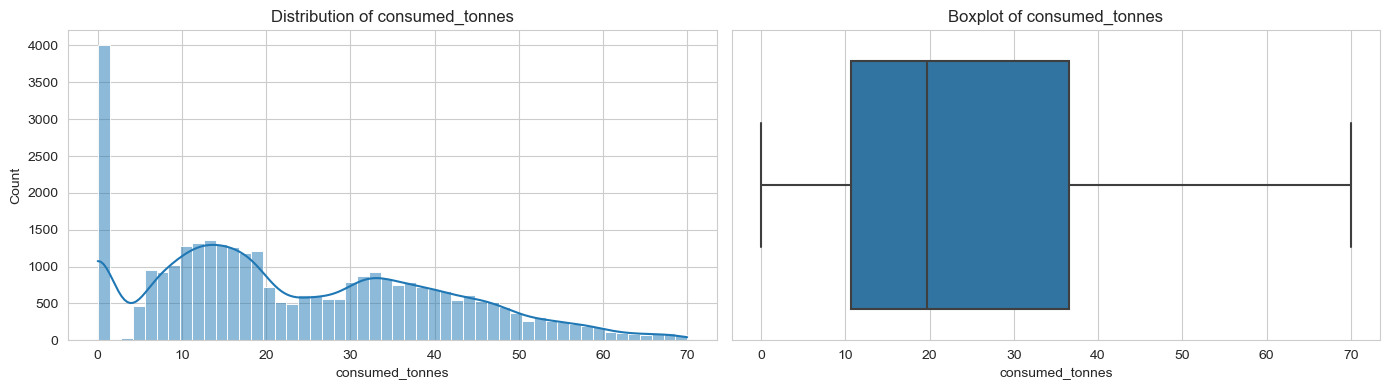

count   32,880.00
mean        23.72
std         16.85
min          0.00
25%         10.71
50%         19.72
75%         36.49
max         69.97
Name: consumed_tonnes, dtype: float64
Skew: 0.437   Kurtosis: -0.674


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[TARGET], kde=True, ax=axes[0], bins=50)
axes[0].set_title("Distribution of consumed_tonnes")
sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot of consumed_tonnes")
plt.tight_layout()
plt.show()

print(df[TARGET].describe())
print(f"Skew: {df[TARGET].skew():.3f}   Kurtosis: {df[TARGET].kurtosis():.3f}")


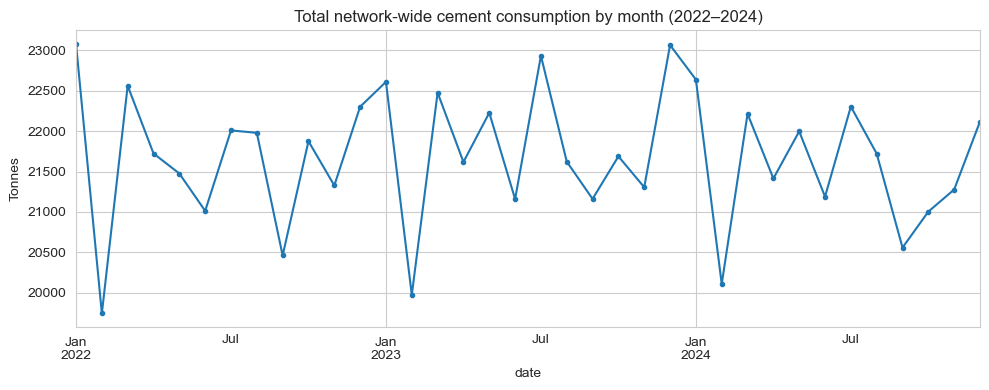

In [7]:
monthly = df.groupby(pd.Grouper(key="date", freq="MS"))[TARGET].sum()
fig, ax = plt.subplots()
monthly.plot(ax=ax, marker="o", markersize=3)
ax.set_title("Total network-wide cement consumption by month (2022–2024)")
ax.set_ylabel("Tonnes")
plt.tight_layout()
plt.show()


**Finding:** `consumed_tonnes` is close to symmetric (skew ≈ 0, no heavy tails) — a
well-behaved target, which is favourable for both SARIMAX and tree-based models. Over time,
total consumption is essentially **flat** across all three years, with no meaningful
year-over-year trend — this is a **stationary** series at the network level, meaning the
forecasting problem is about capturing recurring seasonal/behavioural patterns rather than
projecting growth.


### 1.3 Bivariate Analysis

#### 1.3.1 Numerical Features vs Target

How each numeric feature relates to `consumed_tonnes`, one at a time.


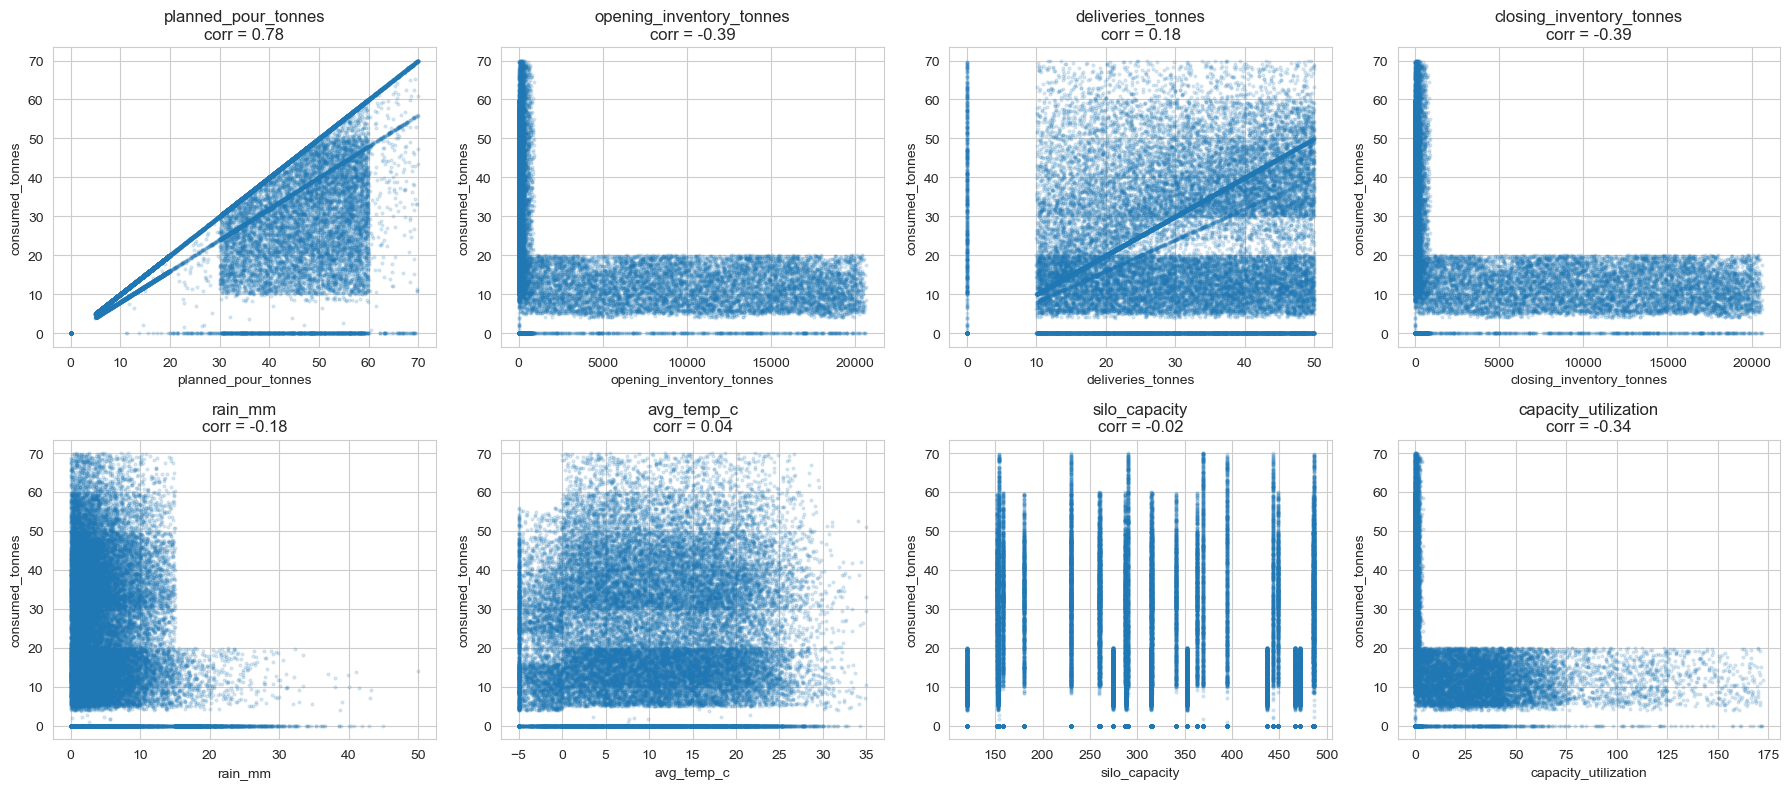

In [8]:
other_numeric = [c for c in numeric_cols if c != TARGET]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, other_numeric):
    ax.scatter(df[col], df[TARGET], s=4, alpha=0.15)
    corr = df[col].corr(df[TARGET])
    ax.set_title(f"{col}\ncorr = {corr:.2f}")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET)
plt.tight_layout()
plt.show()


**Finding:** `planned_pour_tonnes` shows the strongest relationship with the target
(corr ≈ 0.78) — a clear, tight positive scatter. `rain_mm` shows a real but modest negative
relationship (corr ≈ −0.18). `avg_temp_c`, inventory levels, and `silo_capacity` show little to
no linear relationship with the target on their own — they may still matter in combination with
other features (e.g. rain × site behaviour), which is why we don't discard them yet.


#### 1.3.2 Categorical Features vs Target

Does the target's distribution shift meaningfully across categories?


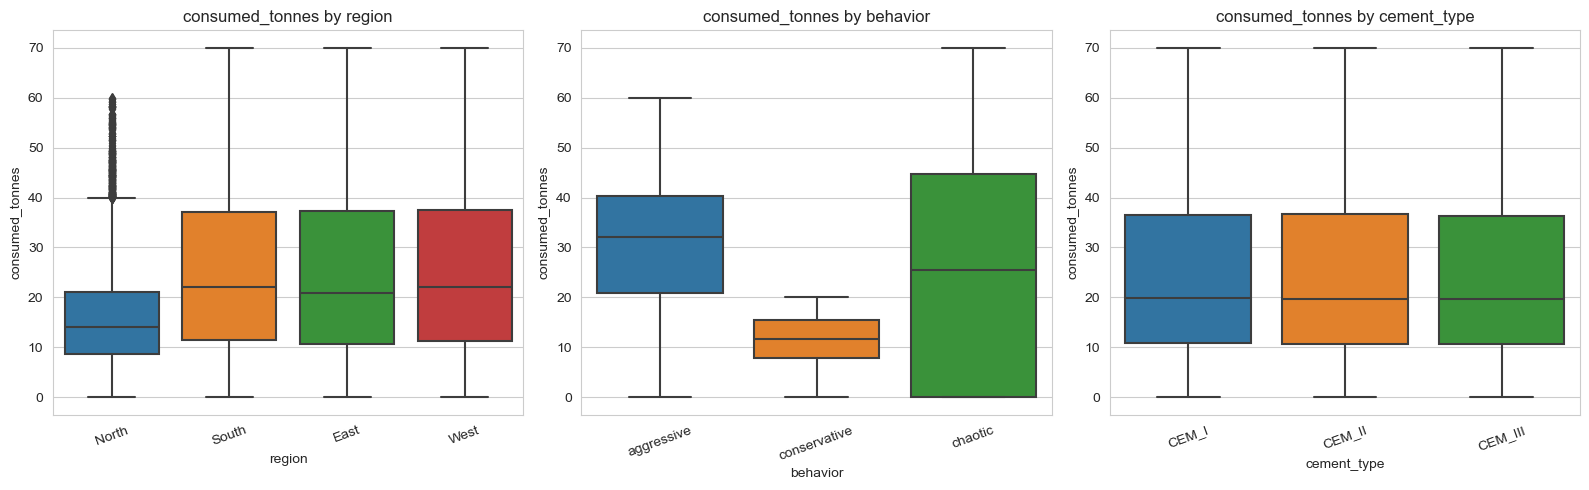

region  behavior      cement_type
East    aggressive    CEM_I         30.55
                      CEM_II        30.00
                      CEM_III       29.20
        chaotic       CEM_I         27.13
                      CEM_II        26.93
                      CEM_III       25.92
        conservative  CEM_I         11.88
                      CEM_II        11.37
                      CEM_III       11.56
North   aggressive    CEM_I         30.04
                      CEM_II        30.78
                      CEM_III       29.62
        conservative  CEM_I         11.15
                      CEM_II        11.25
                      CEM_III       11.56
South   aggressive    CEM_I         30.00
                      CEM_II        29.93
                      CEM_III       30.00
        chaotic       CEM_I         27.16
                      CEM_II        27.06
                      CEM_III       27.40
        conservative  CEM_I         11.70
                      CEM_II        11.59


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes.flat, ["region", "behavior", "cement_type"]):
    sns.boxplot(x=df[col], y=df[TARGET], ax=ax)
    ax.set_title(f"{TARGET} by {col}")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

df.groupby(["region", "behavior", "cement_type"])[TARGET].mean().round(2)


**Finding:** `cement_type` shows almost no difference in the target's distribution across
groups — confirms the profiling-stage observation that type is a bookkeeping dimension, not a
demand driver. `region` and `behavior` show more visible spread differences, though the
*consumption* level itself (as opposed to the inventory-risk metrics from Section 4 later) is
fairly similar across behaviour groups — the real behavioural difference shows up in how sites
manage stock around that consumption, not in the consumption volume itself.


#### 1.3.3 Correlation matrix with the Target Column

All numeric features' correlation with `consumed_tonnes`, ranked.


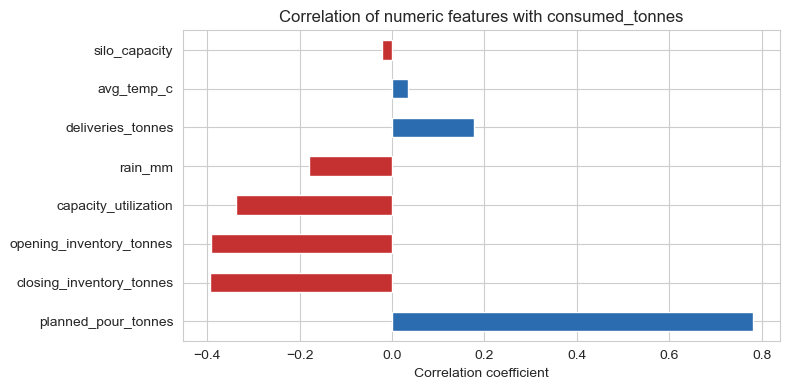

planned_pour_tonnes         0.78
closing_inventory_tonnes   -0.39
opening_inventory_tonnes   -0.39
capacity_utilization       -0.34
rain_mm                    -0.18
deliveries_tonnes           0.18
avg_temp_c                  0.04
silo_capacity              -0.02
Name: consumed_tonnes, dtype: float64

In [10]:
target_corr = df[numeric_cols].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
target_corr.plot(kind="barh", ax=ax, color=["#2b6cb0" if v > 0 else "#c53030" for v in target_corr])
ax.set_title(f"Correlation of numeric features with {TARGET}")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

target_corr


**Finding:** ranked by absolute strength, `planned_pour_tonnes` dominates (0.78), followed
by a modest negative effect from `rain_mm` (−0.18). Everything else sits below |0.1| — weak
linear signal individually, though several (temperature, inventory position) may still
contribute through interactions and lag effects engineered in Step 4.


### 1.4 Multivariate Analysis

#### Heatmap of correlations of numerical features


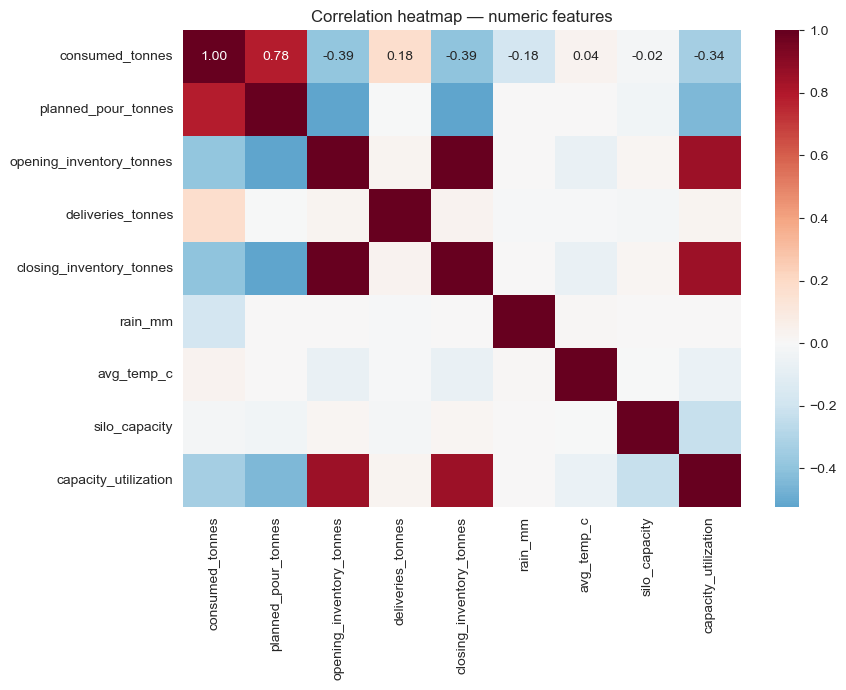

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()


**Reading it:** beyond the target relationships already covered, note the strong
correlation between `closing_inventory_tonnes` and `capacity_utilization` (expected — one is a
scaled version of the other, so we shouldn't feed both into a linear model without care about
multicollinearity). `opening_inventory_tonnes` and `deliveries_tonnes` are largely independent
of `consumed_tonnes` — inventory position doesn't mechanically drive consumption in this data,
which makes sense operationally (you consume what's *planned*, not what happens to be in stock).


#### Scatterplots between key variables

Two pairings worth a closer look, based on what the heatmap and earlier sections flagged as
interesting: the planned-vs-actual relationship split by behaviour, and rainfall's effect split
by region.


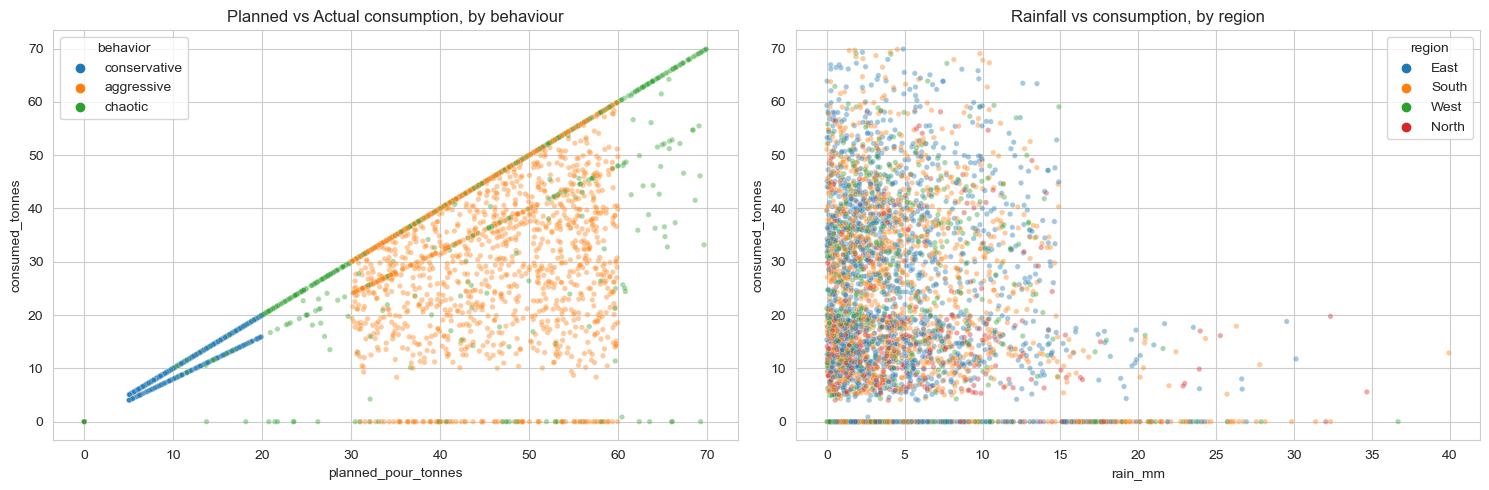

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df.sample(4000, random_state=42), x="planned_pour_tonnes", y=TARGET,
                 hue="behavior", alpha=0.4, s=15, ax=axes[0])
axes[0].set_title("Planned vs Actual consumption, by behaviour")

sns.scatterplot(data=df.sample(4000, random_state=42), x="rain_mm", y=TARGET,
                 hue="region", alpha=0.4, s=15, ax=axes[1])
axes[1].set_title("Rainfall vs consumption, by region")

plt.tight_layout()
plt.show()


**Finding:** the planned-vs-actual relationship holds consistently across all three
behaviour groups — the tight positive line doesn't shift or bend for aggressive/conservative/
chaotic sites, meaning the *planning process* itself isn't where behaviour differences show up
(they show up in stock management, as we found in Section 5 below). Rain's negative effect on
consumption looks broadly consistent across regions too — no single region is driving that
correlation on its own.


#### 3D Scatter Plot

Rainfall, temperature, and consumption together, coloured by site behaviour — checking for any
three-way interaction that a 2D view would miss.


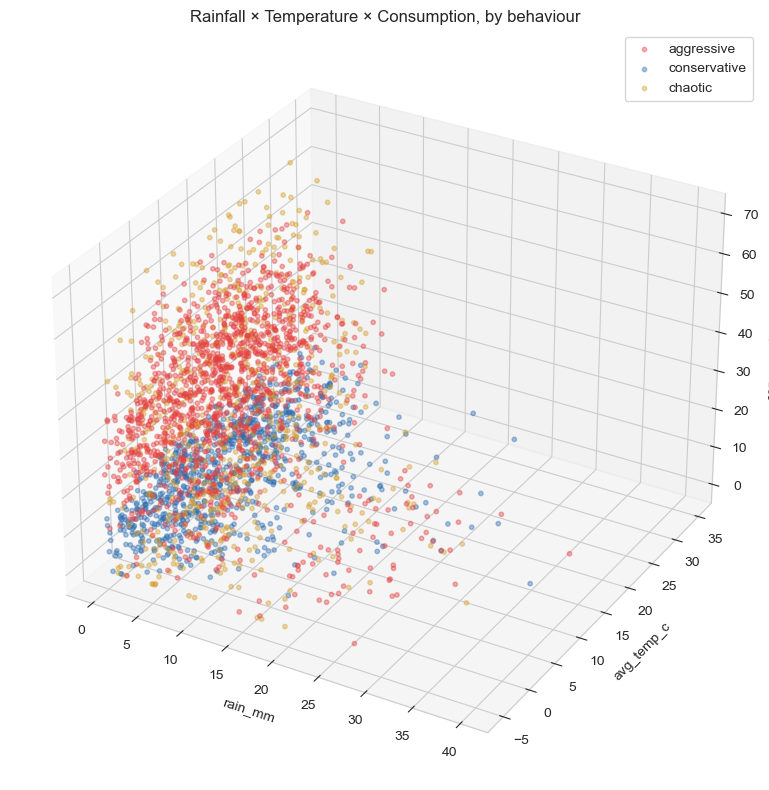

In [13]:
sample = df.sample(3000, random_state=42)
behavior_colors = {"aggressive": "#e53e3e", "conservative": "#2b6cb0", "chaotic": "#d69e2e"}

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection="3d")
for behavior, color in behavior_colors.items():
    subset = sample[sample["behavior"] == behavior]
    ax.scatter(subset["rain_mm"], subset["avg_temp_c"], subset[TARGET],
               c=color, label=behavior, alpha=0.4, s=10)

ax.set_xlabel("rain_mm")
ax.set_ylabel("avg_temp_c")
ax.set_zlabel(TARGET)
ax.set_title("Rainfall × Temperature × Consumption, by behaviour")
ax.legend()
plt.tight_layout()
plt.show()


**Finding:** no visually obvious three-way interaction — the point cloud for each
behaviour group occupies roughly the same region of rain/temperature/consumption space rather
than separating into distinct clusters. This suggests weather affects consumption similarly
regardless of a site's ordering behaviour, so we don't need a weather × behaviour interaction
term as a priority feature in Step 4 — simpler, additive treatment of each is likely sufficient.


## 2. Key Business Finding: Behaviour Drives Inventory Risk (Not Consumption Itself)

The sections above focused on `consumed_tonnes` as the target. But the project brief's actual
pain points — stockouts and overstocking — are about *inventory management around* that
consumption, not the consumption volume itself. This is worth surfacing explicitly, since it's
the clearest business insight in the dataset and directly shapes Steps 4 and 5.


In [14]:
risk_summary = df.groupby("behavior").agg(
    overflow_rate=("over_capacity", "mean"),
    avg_capacity_utilization=("capacity_utilization", "mean"),
    stockout_rate=("stockout_at_pour", "mean"),
    avg_consumed_tonnes=("consumed_tonnes", "mean"),
    n_sites=("site_id", "nunique"),
).round(3)
risk_summary


,overflow_rate,avg_capacity_utilization,stockout_rate,avg_consumed_tonnes,n_sites
behavior,,,,,
aggressive,0.00,0.05,0.57,30.01,14
chaotic,0.22,0.63,0.10,26.82,7
conservative,0.99,38.56,0.00,11.53,9


**Finding:** average daily consumption barely differs across behaviour groups (consistent
with Section 1.3.2), yet the *risk metrics* differ enormously:

- **Aggressive sites** (14): 0% overflow, but miss scheduled pours **57.5%** of the time —
  chronically under-supplied despite normal consumption levels.
- **Conservative sites** (9): 0% stockouts, but average **~39x** their silo capacity in closing
  inventory — large-scale, wasteful overstocking.
- **Chaotic sites** (7): moderate risk on both dimensions.

**Modelling implication:** the forecasting model needs `behavior` as a first-class feature, and
the downstream reorder-point framework (Step 5) needs a different policy per behaviour cluster —
this isn't a "predict demand better" problem alone, it's a "help each site's ordering policy
close the gap to a safe middle ground" problem.


## Summary of EDA findings

| Section | Finding | Modelling implication |
|---|---|---|
| Descriptive stats | Most columns near-symmetric; inventory/utilization heavily right-skewed | May need log-transform or robust scaling for inventory-based features |
| Univariate — target | `consumed_tonnes` symmetric, no heavy tails; network total is flat/stationary over 3 years | No trend component needed; focus on seasonal + behavioural signal |
| Bivariate — numeric vs target | `planned_pour_tonnes` strongest (corr 0.78); `rain_mm` modest negative (−0.18); others weak individually | Use planned pour + rain as core regressors; explore lag/interaction features for the rest |
| Bivariate — categorical vs target | `cement_type` near-flat; `region`/`behavior` show more spread | Treat type as categorical only; behaviour matters more for risk than raw volume |
| Multivariate — heatmap | `closing_inventory` and `capacity_utilization` strongly co-linear (expected) | Avoid feeding both into a linear model without care |
| Multivariate — 3D scatter | No visible 3-way weather×behaviour interaction | Additive weather features likely sufficient, no priority interaction term |
| Key business finding | Behaviour drives inventory *risk*, not consumption volume | `behavior` as a first-class feature; per-cluster reorder policy in Step 5 |

